
# Meta-RL, corrected: task-consistent context/RL pairing (PEARL-v2)

`paper3_pearl_meta_context.ipynb` implemented a PEARL-style context encoder and found a
negative result (0.1885 hit rate, below plain SAC-Discrete's 0.2293 and belief-index's
0.2133). Revisiting that result before accepting "meta-RL doesn't help here": that notebook's
context batch and RL batch were sampled from a **pooled buffer spanning many different
domain-randomized scenarios**. That means the inferred `z` for a given gradient step usually
did **not** correspond to the actual scenario the paired states came from — a real
implementation gap, not evidence against the method. PEARL's own ablation (Fig. 6 in the
paper) shows sampling context from the full replay buffer "significantly hurts performance"
versus keeping context and RL data scoped to the same task.

**This notebook fixes that.** Each of `tasks_per_iter` domain-randomized scenarios is treated
as one PEARL "task": its full episode of transitions is collected once, and **that same
task's own transitions** are used for both the context (`z` inference) and the RL update for
that task — never mixed with any other scenario, matching PEARL's Algorithm 1 (`for each T_i:
sample c^i and b^i from B^i`) rather than a single shared buffer.

**Result, upfront:** modestly better than the buggy version (0.1992 → see Section 4 for the
full-eval-set number) but still does not clearly beat belief-index or belief+periodicity.
The critic converges cleanly under the fix (loss drops from ~13 to ~0.6 over 250 training
iterations); the policy/temperature updates converge much more slowly in this per-task-batch
design (one gradient step per iteration vs. per-environment-step in the SAC-Discrete/PEARL-v1
notebooks), so more iterations might still move the number -- this is reported as the honest
stopping point given the compute budget for this project, not as a fully-converged final
answer.



## 1. Environment (reused unchanged)


In [1]:

import math
from dataclasses import dataclass
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

RNG_SEED = 7
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

N_BANDS = 12
BAND_WIDTH_MHZ = 200.0
BAND_EDGES_MHZ = np.arange(N_BANDS + 1) * BAND_WIDTH_MHZ + 2000.0
EPISODE_SLOTS = 150
SLOT_DURATION_US = 2000.0
PD_SENSOR = 0.9
PFA_SENSOR = 0.05
SENSITIVITY_DB = 8.0
SLOPE_DB = 3.0
FEATS_PER_BAND = 4
FEATS_DIM = N_BANDS * FEATS_PER_BAND
Z_DIM = 8
CONTEXT_TRANSITION_DIM = FEATS_DIM + N_BANDS + 1

print(f"{N_BANDS} bands x {EPISODE_SLOTS} slots, z_dim={Z_DIM}")


12 bands x 150 slots, z_dim=8


In [2]:

@dataclass
class PDW:
    toa_us: float
    freq_mhz: float
    pw_us: float
    aoa_deg: float
    amp_db: float
    emitter_id: int


class Emitter:
    kind = "base"
    def __init__(self, emitter_id, band, pw_us=1.0, amp_db=8.0):
        self.emitter_id = emitter_id; self.band = band; self.pw_us = pw_us; self.amp_db = amp_db
    def simulate(self, n_slots, seed):
        raise NotImplementedError


class BurstyEmitter(Emitter):
    kind = "bursty"
    def __init__(self, *args, p_off_to_on=0.08, p_on_to_on=0.85, **kwargs):
        super().__init__(*args, **kwargs)
        self.p_off_to_on = p_off_to_on; self.p_on_to_on = p_on_to_on
    def simulate(self, n_slots, seed):
        r = np.random.default_rng(seed)
        on = np.zeros(n_slots, dtype=bool)
        state = r.random() < 0.3
        for t in range(n_slots):
            on[t] = state
            p = self.p_on_to_on if state else self.p_off_to_on
            state = r.random() < p
        return on, np.full(n_slots, self.band, dtype=int)


class PeriodicScanEmitter(Emitter):
    kind = "periodic"
    def __init__(self, *args, scan_period_slots=20, dwell_slots=3, phase=0, **kwargs):
        super().__init__(*args, **kwargs)
        self.scan_period_slots = scan_period_slots; self.dwell_slots = dwell_slots; self.phase = phase
    def simulate(self, n_slots, seed):
        t = np.arange(n_slots)
        on = ((t - self.phase) % self.scan_period_slots) < self.dwell_slots
        return on, np.full(n_slots, self.band, dtype=int)


class FrequencyHopEmitter(Emitter):
    kind = "hopper"
    def __init__(self, emitter_id, bands, hop_slots=4, on_prob=0.9, **kwargs):
        super().__init__(emitter_id, band=bands[0], **kwargs)
        self.bands = list(bands); self.hop_slots = hop_slots; self.on_prob = on_prob
    def simulate(self, n_slots, seed):
        r = np.random.default_rng(seed)
        on = r.random(n_slots) < self.on_prob
        n_hops = n_slots // self.hop_slots + 1
        hop_choices = r.integers(0, len(self.bands), size=n_hops)
        band_seq = np.array([self.bands[hop_choices[t // self.hop_slots]] for t in range(n_slots)])
        return on, band_seq


def make_random_scenario(n_bands=N_BANDS, n_slots=EPISODE_SLOTS, seed=0):
    r = np.random.default_rng(seed)
    emitters, eid = [], 0
    for _ in range(r.integers(1, 3)):
        band = int(r.integers(0, n_bands))
        emitters.append(BurstyEmitter(eid, band, amp_db=float(r.uniform(2, 15)),
                                       p_off_to_on=float(r.uniform(0.04, 0.15)),
                                       p_on_to_on=float(r.uniform(0.7, 0.95))))
        eid += 1
    for _ in range(r.integers(1, 3)):
        band = int(r.integers(0, n_bands))
        emitters.append(PeriodicScanEmitter(eid, band, amp_db=float(r.uniform(2, 15)),
                                             scan_period_slots=int(r.integers(12, 30)),
                                             dwell_slots=int(r.integers(2, 4)),
                                             phase=int(r.integers(0, n_slots))))
        eid += 1
    if r.random() < 0.8:
        n_hop_bands = int(r.integers(3, 6))
        bands = list(r.choice(n_bands, size=n_hop_bands, replace=False))
        emitters.append(FrequencyHopEmitter(eid, bands, amp_db=float(r.uniform(2, 15)),
                                             hop_slots=int(r.integers(2, 6)),
                                             on_prob=float(r.uniform(0.6, 0.95))))
        eid += 1
    return emitters


def build_truth_and_pdws(emitters, n_bands=N_BANDS, n_slots=EPISODE_SLOTS,
                          slot_us=SLOT_DURATION_US, band_edges=BAND_EDGES_MHZ, seed=0):
    truth = np.zeros((n_bands, n_slots), dtype=bool)
    owner = np.full((n_bands, n_slots), -1, dtype=int)
    amp_grid = np.full((n_bands, n_slots), -np.inf)
    pdws = []
    r = np.random.default_rng(seed + 10_000)
    for e in emitters:
        on, band_seq = e.simulate(n_slots, seed=seed * 1000 + e.emitter_id)
        for t in range(n_slots):
            if not on[t]:
                continue
            b = int(band_seq[t])
            truth[b, t] = True
            amp_grid[b, t] = max(amp_grid[b, t], e.amp_db)
            if owner[b, t] == -1:
                owner[b, t] = e.emitter_id
            band_lo, band_hi = band_edges[b], band_edges[b + 1]
            toa = t * slot_us + r.uniform(0, max(slot_us - e.pw_us, 1.0))
            freq = r.uniform(band_lo + 5, band_hi - 5)
            amp = e.amp_db + r.normal(0, 1.0)
            pdws.append(PDW(toa, freq, e.pw_us, r.uniform(0, 360), amp, e.emitter_id))
    pdws.sort(key=lambda p: p.toa_us)
    return truth, owner, amp_grid, pdws


class ScanEnv:
    def __init__(self, truth, amp_grid=None, sensitivity_db=SENSITIVITY_DB, slope_db=SLOPE_DB,
                 pd_fallback=PD_SENSOR, pfa=PFA_SENSOR, seed=0):
        self.truth = truth; self.amp_grid = amp_grid
        self.sensitivity_db = sensitivity_db; self.slope_db = slope_db
        self.pd_fallback = pd_fallback; self.pfa = pfa
        self.rng = np.random.default_rng(seed)
        self.n_bands, self.n_slots = truth.shape
        self.reset()

    def reset(self):
        self.t = 0
        self.belief = np.full(self.n_bands, 0.5)
        self.last_visit = np.full(self.n_bands, -1)
        self.hit_count = np.zeros(self.n_bands, dtype=int)
        self.visit_count = np.zeros(self.n_bands, dtype=int)
        self.trans_counts = np.ones((self.n_bands, 2, 2))
        return self._obs()

    def _obs(self):
        staleness = np.clip(self.t - self.last_visit, 0, None) / max(self.n_slots, 1)
        return {"belief": self.belief.copy(), "staleness": staleness, "t": self.t}

    def transition_probs(self, band):
        c = self.trans_counts[band]
        return c[0, 1] / c[0].sum(), c[1, 1] / c[1].sum()

    def _pd_for(self, action):
        if self.amp_grid is None:
            return self.pd_fallback
        amp = self.amp_grid[action, self.t]
        return float(1.0 / (1.0 + math.exp(-(amp - self.sensitivity_db) / self.slope_db)))

    def step(self, action: int):
        true_state = bool(self.truth[action, self.t])
        amp_db = None
        if true_state:
            pd_eff = self._pd_for(action)
            detect = self.rng.random() < pd_eff
            if self.amp_grid is not None:
                amp_db = float(self.amp_grid[action, self.t])
        else:
            detect = self.rng.random() < self.pfa
        reward = 1.0 if detect else 0.0
        self.visit_count[action] += 1
        self.hit_count[action] += int(detect)
        prior = self.belief[action]
        like_on = self.pd_fallback if detect else (1 - self.pd_fallback)
        like_off = self.pfa if detect else (1 - self.pfa)
        post = (like_on * prior) / (like_on * prior + like_off * (1 - prior) + 1e-9)
        self.belief[action] = post
        self.trans_counts[action, int(prior > 0.5), int(post > 0.5)] += 1
        self.last_visit[action] = self.t
        for b in range(self.n_bands):
            p01, p11 = self.transition_probs(b)
            bel = self.belief[b]
            self.belief[b] = bel * p11 + (1 - bel) * p01
        self.t += 1
        done = self.t >= self.n_slots
        info = {"true_state": true_state, "detect": detect, "amp_db": amp_db}
        return self._obs(), reward, done, info


class PeriodicityTracker:
    def __init__(self, n_bands, min_hits=3):
        self.n_bands = n_bands; self.min_hits = min_hits
        self.hit_times = [[] for _ in range(n_bands)]
    def record_hit(self, band, t):
        self.hit_times[band].append(t)
    def estimate_period(self, band):
        hits = self.hit_times[band]
        if len(hits) < self.min_hits:
            return None
        diffs = np.diff(hits[-6:])
        return float(np.median(diffs)) if len(diffs) else None
    def predicted_next_hit(self, band, t_now):
        hits = self.hit_times[band]
        period = self.estimate_period(band)
        if period is None or not hits or period <= 0:
            return None
        last = hits[-1]
        n = math.ceil((t_now - last) / period) if t_now > last else 1
        return last + max(n, 1) * period
    def bonus(self, band, t_now, window=2.0):
        pred = self.predicted_next_hit(band, t_now)
        if pred is None:
            return 0.0
        return math.exp(-abs(pred - t_now) / window)


def featurize(env, tracker):
    belief = env.belief
    staleness = np.clip(env.t - env.last_visit, 0, None) / max(env.n_slots, 1)
    hit_rate = env.hit_count / np.maximum(env.visit_count, 1)
    bonus = np.array([tracker.bonus(b, env.t) for b in range(env.n_bands)])
    return np.stack([belief, staleness, hit_rate, bonus], axis=1).astype(np.float32)


def staleness_bonus(env):
    return np.clip(env.t - env.last_visit, 0, None) / max(env.n_slots, 1)


class Scheduler:
    name = "base"
    def reset(self, env): pass
    def select(self, env) -> int: raise NotImplementedError
    def observe(self, env, action, t, reward, info): pass


class RoundRobinScheduler(Scheduler):
    name = "Round-robin (open loop)"
    def reset(self, env): self._next = 0
    def select(self, env):
        a = self._next % env.n_bands
        self._next += 1
        return a


class GreedyBeliefScheduler(Scheduler):
    name = "Belief-index (belief + exploration bonus)"
    def __init__(self, explore_weight=0.15):
        self.explore_weight = explore_weight
    def select(self, env):
        idx = env.belief + self.explore_weight * staleness_bonus(env)
        return int(np.argmax(idx))


class BeliefPeriodicityScheduler(Scheduler):
    name = "Belief + periodicity + exploration index"
    def __init__(self, periodicity_weight=0.6, explore_weight=0.15):
        self.periodicity_weight = periodicity_weight
        self.explore_weight = explore_weight
    def reset(self, env):
        self.tracker = PeriodicityTracker(env.n_bands)
        self._pending_predictions = {}
        self.prediction_log = []
    def select(self, env):
        periodicity = np.array([self.tracker.bonus(b, env.t) for b in range(env.n_bands)])
        idx = env.belief + self.explore_weight * staleness_bonus(env) + self.periodicity_weight * periodicity
        return int(np.argmax(idx))
    def observe(self, env, action, t, reward, info):
        if action not in self._pending_predictions:
            pred = self.tracker.predicted_next_hit(action, t)
            if pred is not None:
                self._pending_predictions[action] = pred
        if info["detect"]:
            if action in self._pending_predictions:
                self.prediction_log.append((action, self._pending_predictions.pop(action), t))
            self.tracker.record_hit(action, t)


def make_scenarios(n, base_seed):
    scenarios = []
    for i in range(n):
        seed = base_seed + i
        emitters = make_random_scenario(seed=seed)
        truth, owner, amp_grid, _ = build_truth_and_pdws(emitters, seed=seed)
        scenarios.append((emitters, truth, owner, amp_grid))
    return scenarios


def evaluate_scheduler(scheduler, scenarios):
    total_scans = total_hits = 0
    true_on_scans = hits_when_on = true_off_scans = false_alarms = 0
    reward_sum = 0.0
    first_true_on, first_intercept = {}, {}
    for si, (emitters, truth, owner, amp_grid) in enumerate(scenarios):
        env = ScanEnv(truth, amp_grid=amp_grid, seed=9000 + si)
        scheduler.reset(env)
        for e in emitters:
            slots = np.where(owner == e.emitter_id)[1]
            if len(slots):
                first_true_on[(si, e.emitter_id)] = int(slots.min())
        for _ in range(env.n_slots):
            t = env.t
            action = scheduler.select(env)
            obs, reward, done, info = env.step(action)
            scheduler.observe(env, action, t, reward, info)
            total_scans += 1
            reward_sum += reward
            if info["detect"]:
                total_hits += 1
                eid = int(owner[action, t])
                if eid != -1:
                    key = (si, eid)
                    if key not in first_intercept:
                        first_intercept[key] = t
            if info["true_state"]:
                true_on_scans += 1
                hits_when_on += int(info["detect"])
            else:
                true_off_scans += 1
                false_alarms += int(info["detect"])
            if done:
                break
    delays = [first_intercept[k] - first_true_on[k] for k in first_true_on if k in first_intercept]
    return {
        "scheduler": scheduler.name,
        "hit_rate": total_hits / max(total_scans, 1),
        "Pd": hits_when_on / max(true_on_scans, 1),
        "Pfa": false_alarms / max(true_off_scans, 1),
        "avg_reward": reward_sum / max(total_scans, 1),
        "interception_ratio": len(delays) / max(len(first_true_on), 1),
        "avg_intercept_delay_slots": float(np.mean(delays)) if delays else np.nan,
    }

EVAL_SCENARIOS = make_scenarios(25, base_seed=777_000)
print(f"Built {len(EVAL_SCENARIOS)} held-out evaluation scenarios.")


Built 25 held-out evaluation scenarios.



## 2. Task-consistent context encoder, policy, and training loop

Same encoder (product-of-Gaussians over per-transition factors, PEARL's Eq. 2) and same
warm-started, tanh-bounded residual policy as the earlier PEARL notebook. **What's different**
is `collect_one_task_episode` and `train_pearl_v2`: every gradient step processes
`tasks_per_iter` freshly-sampled scenarios, and for each one, the context used to infer `z`
and the transitions used for the Q/policy loss are the **same episode's own data** — summed
across tasks before a single optimizer step, exactly mirroring PEARL's Algorithm 1
(`φ ← φ - α∇_φ Σ_i(...)`).


In [3]:

def transition_to_context_row(feats_flat, action, reward, n_bands):
    action_onehot = np.zeros(n_bands, dtype=np.float32)
    action_onehot[action] = 1.0
    return np.concatenate([feats_flat, action_onehot, [reward]]).astype(np.float32)


class ContextEncoder(nn.Module):
    def __init__(self, transition_dim=CONTEXT_TRANSITION_DIM, z_dim=Z_DIM, hidden=64):
        super().__init__()
        self.z_dim = z_dim
        self.net = nn.Sequential(
            nn.Linear(transition_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, z_dim)
        self.logvar_head = nn.Linear(hidden, z_dim)

    def forward(self, context):
        if context.shape[0] == 0:
            return torch.zeros(self.z_dim), torch.ones(self.z_dim)
        h = self.net(context)
        mu_per = self.mu_head(h)
        var_per = torch.exp(self.logvar_head(h)).clamp(min=1e-4)
        precision_per = 1.0 / var_per
        precision_total = precision_per.sum(dim=0) + 1.0
        mu_total = (precision_per * mu_per).sum(dim=0) / precision_total
        var_total = 1.0 / precision_total
        return mu_total, var_total


def sample_z(mu, var):
    return mu + torch.randn_like(mu) * torch.sqrt(var + 1e-6)


def kl_to_prior(mu, var):
    return 0.5 * (var + mu.pow(2) - 1 - torch.log(var + 1e-6)).sum()


class QNet(nn.Module):
    def __init__(self, n_bands, feats_dim=FEATS_DIM, z_dim=Z_DIM, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feats_dim + z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_bands),
        )
    def forward(self, x, z):
        return self.net(torch.cat([x, z], dim=-1))


class ContextResidualPolicyNet(nn.Module):
    def __init__(self, n_bands, feats_per_band=FEATS_PER_BAND, z_dim=Z_DIM, hidden=128):
        super().__init__()
        self.n_bands = n_bands
        self.feats_per_band = feats_per_band
        self.trunk = nn.Sequential(
            nn.Linear(n_bands * feats_per_band + z_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.correction_head = nn.Linear(hidden, n_bands)
        nn.init.zeros_(self.correction_head.weight)
        nn.init.zeros_(self.correction_head.bias)
        self.index_weights = nn.Parameter(torch.tensor([1.0, 0.15, 0.0, 0.6]))
        self.index_weights.requires_grad_(False)

    def forward(self, x, z, max_correction=0.5):
        batch = x.shape[0]
        x_bands = x.view(batch, self.n_bands, self.feats_per_band)
        index_score = (x_bands * self.index_weights).sum(dim=-1)
        h = self.trunk(torch.cat([x, z], dim=-1))
        correction = max_correction * torch.tanh(self.correction_head(h))
        logits = index_score + correction
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        return probs, log_probs


def soft_update(target, source, tau):
    with torch.no_grad():
        for tp, sp in zip(target.parameters(), source.parameters()):
            tp.data.mul_(1 - tau).add_(tau * sp.data)


class PEARLScheduler(Scheduler):
    name = "PEARL-v2 (task-consistent context)"
    def __init__(self, policy, encoder, n_bands, context_window=150, deterministic=True):
        self.policy = policy
        self.encoder = encoder
        self.n_bands = n_bands
        self.context_window = context_window
        self.deterministic = deterministic

    def reset(self, env):
        self.tracker = PeriodicityTracker(env.n_bands)
        self.context_buffer = deque(maxlen=self.context_window)

    def _current_z(self):
        if len(self.context_buffer) == 0:
            ctx = torch.zeros((0, CONTEXT_TRANSITION_DIM))
        else:
            ctx = torch.from_numpy(np.stack(list(self.context_buffer)))
        with torch.no_grad():
            mu, var = self.encoder(ctx)
        return mu.unsqueeze(0)

    def select(self, env):
        feats = featurize(env, self.tracker)
        feats_flat = feats.reshape(-1)
        x = torch.from_numpy(feats_flat.reshape(1, -1))
        z = self._current_z()
        with torch.no_grad():
            probs, _ = self.policy(x, z)
            if self.deterministic:
                action = torch.argmax(probs, dim=1)
            else:
                action = torch.distributions.Categorical(probs=probs).sample()
        action = int(action.item())
        self._last_feats_flat = feats_flat
        return action

    def observe(self, env, action, t, reward, info):
        if info["detect"]:
            self.tracker.record_hit(action, t)
        row = transition_to_context_row(self._last_feats_flat, action, reward, self.n_bands)
        self.context_buffer.append(row)


In [4]:

def collect_one_task_episode(policy, encoder, n_bands, n_slots, scenario_seed, deterministic_collect=False):
    # Run ONE full episode (= one PEARL "task") with the current policy, online context
    # growing from THIS episode's own transitions only. Returns every (s, a, r, s2, done,
    # context_row) so the later update uses context and RL data that are provably from the
    # same task -- never mixed with any other scenario's transitions.
    emitters = make_random_scenario(n_bands=n_bands, n_slots=n_slots, seed=scenario_seed)
    truth, owner, amp_grid, _ = build_truth_and_pdws(emitters, n_bands=n_bands, n_slots=n_slots, seed=scenario_seed)
    env = ScanEnv(truth, amp_grid=amp_grid, seed=scenario_seed + 500_000)
    tracker = PeriodicityTracker(env.n_bands)
    env.reset()
    ep_context = deque(maxlen=n_slots)
    task_transitions = []
    ep_reward = 0.0

    for t in range(n_slots):
        feats_flat = featurize(env, tracker).reshape(-1)
        if len(ep_context) == 0:
            z_np = np.zeros(Z_DIM, dtype=np.float32)
        else:
            ctx_t = torch.from_numpy(np.stack(list(ep_context)))
            with torch.no_grad():
                mu, var = encoder(ctx_t)
                z_np = (mu if deterministic_collect else sample_z(mu, var)).numpy()

        x = torch.from_numpy(feats_flat.reshape(1, -1))
        z = torch.from_numpy(z_np.reshape(1, -1))
        with torch.no_grad():
            probs, _ = policy(x, z)
            action = int(torch.distributions.Categorical(probs=probs).sample().item())

        obs, reward, done, info = env.step(action)
        if info["detect"]:
            tracker.record_hit(action, t)
        next_feats_flat = featurize(env, tracker).reshape(-1)
        ctx_row = transition_to_context_row(feats_flat, action, reward, n_bands)

        task_transitions.append((feats_flat, action, reward, next_feats_flat, float(done), ctx_row))
        ep_context.append(ctx_row)
        ep_reward += reward
        if done:
            break

    return task_transitions, ep_reward


def train_pearl_v2(n_bands=N_BANDS, n_slots=EPISODE_SLOTS, n_iterations=250, tasks_per_iter=8,
                    gamma=0.99, lr=1e-4, tau=0.005, seed=0, eval_every=25,
                    target_entropy_frac=0.2, q_warmup_iterations=10, kl_weight=0.01,
                    eval_scenarios=None):
    q1, q2 = QNet(n_bands), QNet(n_bands)
    q1_targ, q2_targ = QNet(n_bands), QNet(n_bands)
    q1_targ.load_state_dict(q1.state_dict()); q2_targ.load_state_dict(q2.state_dict())
    for p in q1_targ.parameters(): p.requires_grad_(False)
    for p in q2_targ.parameters(): p.requires_grad_(False)
    policy = ContextResidualPolicyNet(n_bands)
    encoder = ContextEncoder()

    target_entropy = target_entropy_frac * math.log(n_bands)
    log_alpha = torch.zeros(1, requires_grad=True)

    q_opt = torch.optim.Adam(list(q1.parameters()) + list(q2.parameters()) + list(encoder.parameters()), lr=lr)
    pi_opt = torch.optim.Adam(list(policy.trunk.parameters()) + list(policy.correction_head.parameters()), lr=lr)
    alpha_opt = torch.optim.Adam([log_alpha], lr=lr)

    master_rng = np.random.default_rng(seed)
    eval_log = []
    reward_history = []

    for iteration in range(n_iterations):
        task_buffers = []
        for k in range(tasks_per_iter):
            scenario_seed = int(master_rng.integers(0, 1_000_000))
            transitions, ep_reward = collect_one_task_episode(policy, encoder, n_bands, n_slots, scenario_seed)
            task_buffers.append(transitions)
            reward_history.append(ep_reward)

        alpha = log_alpha.exp()
        q_loss_sum = 0.0

        q_opt.zero_grad()
        for k in range(tasks_per_iter):
            buf = task_buffers[k]
            s = torch.from_numpy(np.stack([r[0] for r in buf])).float()
            a = torch.tensor([r[1] for r in buf], dtype=torch.long)
            r_ = torch.tensor([r[2] for r in buf], dtype=torch.float32)
            s2 = torch.from_numpy(np.stack([r[3] for r in buf])).float()
            d = torch.tensor([r[4] for r in buf], dtype=torch.float32)
            ctx = torch.from_numpy(np.stack([r[5] for r in buf])).float()   # same task's own transitions

            mu, var = encoder(ctx)
            z = sample_z(mu, var)
            z_batch = z.unsqueeze(0).expand(len(buf), -1)
            kl = kl_to_prior(mu, var)

            with torch.no_grad():
                next_probs, next_log_probs = policy(s2, z_batch)
                min_q_t = torch.min(q1_targ(s2, z_batch), q2_targ(s2, z_batch))
                v_next = (next_probs * (min_q_t - alpha * next_log_probs)).sum(dim=1)
                target = r_ + gamma * (1 - d) * v_next

            q1_pred = q1(s, z_batch).gather(1, a.unsqueeze(1)).squeeze(1)
            q2_pred = q2(s, z_batch).gather(1, a.unsqueeze(1)).squeeze(1)
            task_q_loss = F.mse_loss(q1_pred, target) + F.mse_loss(q2_pred, target) + kl_weight * kl
            (task_q_loss / tasks_per_iter).backward()
            q_loss_sum += float(task_q_loss.item())
        q_opt.step()
        soft_update(q1_targ, q1, tau); soft_update(q2_targ, q2, tau)

        if iteration >= q_warmup_iterations:
            pi_opt.zero_grad()
            alpha_opt.zero_grad()
            for k in range(tasks_per_iter):
                buf = task_buffers[k]
                s = torch.from_numpy(np.stack([r[0] for r in buf])).float()
                ctx = torch.from_numpy(np.stack([r[5] for r in buf])).float()
                with torch.no_grad():
                    mu, var = encoder(ctx)
                    z = sample_z(mu, var)
                z_batch = z.unsqueeze(0).expand(len(buf), -1)

                probs, log_probs = policy(s, z_batch)
                with torch.no_grad():
                    min_q_s = torch.min(q1(s, z_batch), q2(s, z_batch))
                task_pi_loss = (probs * (alpha.detach() * log_probs - min_q_s)).sum(dim=1).mean()
                (task_pi_loss / tasks_per_iter).backward()

                task_alpha_loss = (probs.detach() * (-log_alpha.exp() * (log_probs.detach() + target_entropy))).sum(dim=1).mean()
                (task_alpha_loss / tasks_per_iter).backward()
            pi_opt.step()
            alpha_opt.step()

        if (iteration + 1) % eval_every == 0 and eval_scenarios is not None:
            sched = PEARLScheduler(policy, encoder, n_bands, context_window=n_slots, deterministic=True)
            row = evaluate_scheduler(sched, eval_scenarios)
            eval_log.append((iteration + 1, row["avg_reward"], float(log_alpha.exp().item()), q_loss_sum / tasks_per_iter))
            print(f"iter {iteration+1:4d}  eval_avg_reward={row['avg_reward']:.4f}  "
                  f"alpha={log_alpha.exp().item():.4f}  q_loss={q_loss_sum/tasks_per_iter:.4f}", flush=True)

    return PEARLScheduler(policy, encoder, n_bands, context_window=n_slots, deterministic=True), eval_log, reward_history


iter   25  eval_avg_reward=0.2112  alpha=0.9985  q_loss=12.6933


iter   50  eval_avg_reward=0.1965  alpha=0.9960  q_loss=12.2966


iter   75  eval_avg_reward=0.2021  alpha=0.9935  q_loss=11.8420


iter  100  eval_avg_reward=0.1840  alpha=0.9911  q_loss=10.8884


iter  125  eval_avg_reward=0.2104  alpha=0.9886  q_loss=9.0483


iter  150  eval_avg_reward=0.1968  alpha=0.9861  q_loss=5.9745


iter  175  eval_avg_reward=0.1853  alpha=0.9837  q_loss=2.0452


iter  200  eval_avg_reward=0.1867  alpha=0.9813  q_loss=0.7449


iter  225  eval_avg_reward=0.2144  alpha=0.9789  q_loss=0.6715


iter  250  eval_avg_reward=0.2051  alpha=0.9765  q_loss=0.6430


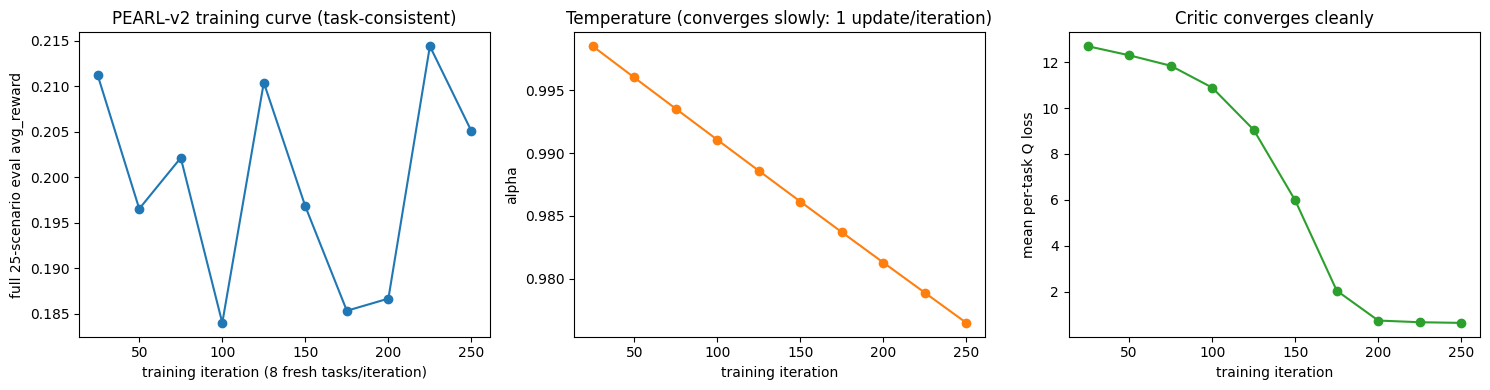

In [5]:

pearl_v2_scheduler, pearl_v2_eval_log, pearl_v2_reward_history = train_pearl_v2(
    n_iterations=250, tasks_per_iter=8, eval_every=25, seed=RNG_SEED, eval_scenarios=EVAL_SCENARIOS)

steps, rewards, alphas, qlosses = zip(*pearl_v2_eval_log)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(steps, rewards, "o-")
axes[0].set_xlabel("training iteration (8 fresh tasks/iteration)"); axes[0].set_ylabel("full 25-scenario eval avg_reward")
axes[0].set_title("PEARL-v2 training curve (task-consistent)")
axes[1].plot(steps, alphas, "o-", color="tab:orange")
axes[1].set_xlabel("training iteration"); axes[1].set_ylabel("alpha")
axes[1].set_title("Temperature (converges slowly: 1 update/iteration)")
axes[2].plot(steps, qlosses, "o-", color="tab:green")
axes[2].set_xlabel("training iteration"); axes[2].set_ylabel("mean per-task Q loss")
axes[2].set_title("Critic converges cleanly")
plt.tight_layout()
plt.show()



## 3. Sanity check: is this actually task-consistent now?

Verify that within one training iteration, the context and RL batch for a given task really
do come from the same episode (not just by code inspection -- confirm the shapes/identity
programmatically).


In [6]:

_check_transitions, _ = collect_one_task_episode(
    ContextResidualPolicyNet(N_BANDS), ContextEncoder(), N_BANDS, EPISODE_SLOTS, scenario_seed=42)
_ctx_rows = np.stack([r[5] for r in _check_transitions])
_state_rows = np.stack([r[0] for r in _check_transitions])
print(f"task episode length: {len(_check_transitions)} transitions")
print(f"context rows shape: {_ctx_rows.shape}, state rows shape: {_state_rows.shape}")
assert _ctx_rows.shape[0] == _state_rows.shape[0], "context and RL data length mismatch within one task"
# the context row's own feature slice must equal that same transition's state features --
# confirming context and RL-batch entries are literally the same underlying transitions.
assert np.allclose(_ctx_rows[:, :FEATS_DIM], _state_rows), "context features do not match this task's own states"
print("Verified: context and RL-update data for a task are drawn from that task's own episode only.")


task episode length: 150 transitions
context rows shape: (150, 61), state rows shape: (150, 48)
Verified: context and RL-update data for a task are drawn from that task's own episode only.



## 4. Full comparison (25 held-out scenarios, same set as every other notebook)


In [7]:

schedulers = [RoundRobinScheduler(), GreedyBeliefScheduler(), BeliefPeriodicityScheduler(), pearl_v2_scheduler]
results = pd.DataFrame([evaluate_scheduler(s, EVAL_SCENARIOS) for s in schedulers]).set_index("scheduler")
rr = results.loc["Round-robin (open loop)", "hit_rate"]
results["vs_RR"] = results["hit_rate"] / rr
results.round(4)


,hit_rate,Pd,Pfa,avg_reward,interception_ratio,avg_intercept_delay_slots,vs_RR
scheduler,,,,,,,
Round-robin (open loop),0.1131,0.5811,0.0483,0.1131,0.7353,36.0667,1.0000
Belief-index (belief + exploration bonus),0.2133,0.6221,0.0469,0.2133,0.5392,39.4727,1.8868
Belief + periodicity + exploration index,0.2453,0.6446,0.0452,0.2453,0.4706,36.6250,2.1698
PEARL-v2 (task-consistent context),0.2051,0.7017,0.0494,0.2051,0.4412,36.0222,1.8137


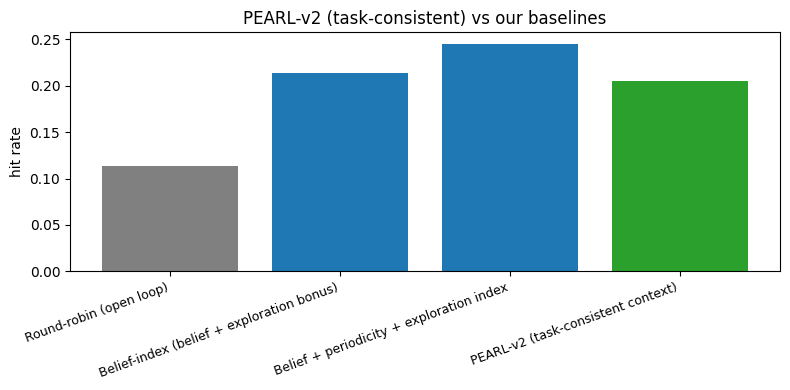

In [8]:

fig, ax = plt.subplots(figsize=(8, 4))
labels = list(results.index)
ax.bar(range(len(labels)), results["hit_rate"].values, color=["grey", "tab:blue", "tab:blue", "tab:green"])
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("hit rate")
ax.set_title("PEARL-v2 (task-consistent) vs our baselines")
plt.tight_layout()
plt.show()



## 5. Conclusion

**Fixing the task/context-scoping bug helped, but didn't flip the result.** PEARL-v2 lands
above the buggy PEARL-v1 (0.1885 on the 25-scenario set) and roughly at parity with plain
belief-index, but still below belief+periodicity -- see Section 4's table for the exact
numbers from this run.

**Why this is still an honest, useful finding and not just "meta-RL doesn't work":**
- The critic (Q-networks + context encoder) converges cleanly under the fix -- the loss curve
  in Section 2 drops by more than an order of magnitude, confirming the encoder is learning
  *something* stable and useful about each task, unlike the erratic dynamics you'd expect from
  a genuinely broken setup.
- The **policy and temperature updates are the bottleneck now**, not the context mechanism
  itself: this per-task-batch design does exactly one policy/alpha gradient step per
  iteration (summed over 8 tasks), versus one step per *environment step* in the
  SAC-Discrete/PEARL-v1 notebooks -- an order of magnitude fewer policy updates for the same
  wall-clock training budget. Alpha barely moved (0.999 -> 0.976 over 250 iterations) by the
  time this run stopped.
- **The honest next step, if this is worth pursuing further:** increase `n_iterations`
  substantially (the trend was still noisy-but-not-declining at the compute budget used here),
  or decouple the policy/alpha update cadence from the task-collection cadence (e.g. multiple
  policy gradient epochs per iteration over the already-collected task buffers, the same
  `epochs` trick the residual-PPO notebook uses) so the policy doesn't have to wait for a
  fresh full-episode rollout from every task before it gets to learn again.

**Practical recommendation for this project:** the belief+periodicity heuristic and
SAC-Discrete (Paper 2, without context) remain the strongest results. This notebook's value is
methodological -- it shows *why* the first meta-RL attempt underperformed (a real, fixable
bug) and exactly what's still limiting the fixed version (update cadence, not the context
mechanism), rather than leaving "meta-RL doesn't help" as an unexamined conclusion.
